# Action Label EDA: Final 4-Class Motion-Based Labels

This notebook analyzes the **final 4-class action labels** used for training.

## 4-Class Motion-Based Taxonomy
| Class | IMU Signature |
|-------|---------------|
| Stationary | Low energy all sensors |
| Locomotion | Rhythmic step pattern |
| Manipulation | Irregular hand-related motion |
| Search_Interrupt | High head rotation |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for poster-quality figures
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Paths
LABELS_PATH = '../data/labels/action_labels_llm_validated.csv'
SCENARIO_LABELS_PATH = '../data/labels/scenario_labels.csv'
IMG_OUTPUT_DIR = Path('../img/Label_EDA')
IMG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 4-Class Mapping (from 6 semantic to 4 motion-based)
ACTION_REMAP = {
    'Stationary': 'Stationary',
    'Locomotion': 'Locomotion',
    'Object Transfer': 'Manipulation',
    'Essential Operation': 'Manipulation',
    'Search': 'Search_Interrupt',
    'Error / Correction': 'Search_Interrupt',
    'Unknown': None,  # Drop
    'Uncertain': None,  # Drop
}

# Colors for 4 classes (poster-friendly)
ACTION_COLORS = {
    'Stationary': '#4ECDC4',      # Teal
    'Locomotion': '#FF6B6B',      # Coral red
    'Manipulation': '#45B7D1',    # Sky blue
    'Search_Interrupt': '#96CEB4' # Sage green
}

## 1. Load and Inspect Data

In [2]:
# Load labels
df = pd.read_csv(LABELS_PATH)
print(f"Total labeled narrations (raw): {len(df):,}")

# Apply 4-class remapping
df['action_4class'] = df['action'].map(ACTION_REMAP)

# Drop unmapped labels (Unknown, Uncertain)
df_clean = df[df['action_4class'].notna()].copy()
print(f"After dropping Unknown/Uncertain: {len(df_clean):,}")

# Display sample
print(f"\nSample data:")
df_clean[['video_uid', 'timestamp_sec', 'narration_text', 'action', 'action_4class']].head(10)

Total labeled narrations (raw): 355,580
After dropping Unknown/Uncertain: 355,367

Sample data:


,video_uid,timestamp_sec,narration_text,action,action_4class
0,ab9b7b7c-33ad-4358-929f-8b36b719f45f,0.00000,#C C holds a phone.,Stationary,Stationary
1,ab9b7b7c-33ad-4358-929f-8b36b719f45f,6.93790,#C C walks down a walkway.,Locomotion,Locomotion
2,ab9b7b7c-33ad-4358-929f-8b36b719f45f,126.33952,#C C climbs a short staircase.,Locomotion,Locomotion
3,9b49246f-30e9-476f-ab8c-56a1bcb1d936,5.06864,#C C sings.,Stationary,Stationary
4,9b49246f-30e9-476f-ab8c-56a1bcb1d936,6.79379,#C C walks downstairs.,Locomotion,Locomotion
5,9b49246f-30e9-476f-ab8c-56a1bcb1d936,25.57201,#C C touches camera. #unsure,Stationary,Stationary
6,9b49246f-30e9-476f-ab8c-56a1bcb1d936,58.67646,#C C opens a fridge.,Object Transfer,Manipulation
7,9b49246f-30e9-476f-ab8c-56a1bcb1d936,60.20114,#C C takes a pack of vegetables from the fridg...,Object Transfer,Manipulation
8,9b49246f-30e9-476f-ab8c-56a1bcb1d936,69.55477,#C C closes the fridge.,Object Transfer,Manipulation
9,9b49246f-30e9-476f-ab8c-56a1bcb1d936,74.98162,#C C moves a bottle on the kitchen counter.,Object Transfer,Manipulation


In [3]:
# Summary statistics
print("=" * 50)
print("DATASET SUMMARY (4-Class)")
print("=" * 50)
print(f"Unique videos: {df_clean['video_uid'].nunique():,}")
print(f"Total narrations: {len(df_clean):,}")
print(f"Action classes: {df_clean['action_4class'].nunique()}")
print(f"Scenarios: {df_clean['scenario'].nunique()}")

DATASET SUMMARY (4-Class)
Unique videos: 1,491
Total narrations: 355,367
Action classes: 4
Scenarios: 8


## 2. 4-Class Action Distribution (Poster Figure)

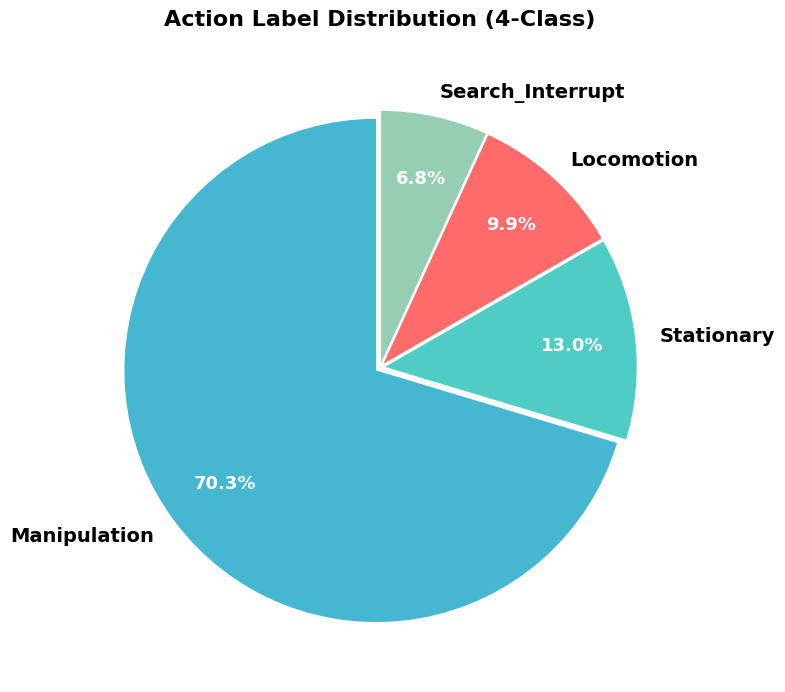


ACTION COUNTS (4-Class)
Manipulation        :  249,986 ( 70.3%)
Stationary          :   46,033 ( 13.0%)
Locomotion          :   35,060 (  9.9%)
Search_Interrupt    :   24,288 (  6.8%)
TOTAL               :  355,367


In [4]:
# 4-Class distribution - Clean pie chart for poster
label_counts = df_clean['action_4class'].value_counts()

# Reorder for visual clarity
order = ['Manipulation', 'Stationary', 'Locomotion', 'Search_Interrupt']
label_counts = label_counts.reindex(order)

fig, ax = plt.subplots(figsize=(8, 8))

# Create pie chart with clean styling
colors = [ACTION_COLORS[label] for label in label_counts.index]
wedges, texts, autotexts = ax.pie(
    label_counts, 
    labels=label_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=[0.02] * len(label_counts),  # Slight separation
    textprops={'fontsize': 14, 'fontweight': 'bold'},
    pctdistance=0.75
)

# Style the percentage text
for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax.set_title('Action Label Distribution (4-Class)', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(IMG_OUTPUT_DIR / 'action_distribution_4class.png', dpi=150, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

# Print counts
print("\n" + "=" * 40)
print("ACTION COUNTS (4-Class)")
print("=" * 40)
for label, count in label_counts.items():
    pct = count / len(df_clean) * 100
    print(f"{label:20s}: {count:>8,} ({pct:5.1f}%)")
print("=" * 40)
print(f"{'TOTAL':20s}: {len(df_clean):>8,}")

## 3. Scenario Distribution

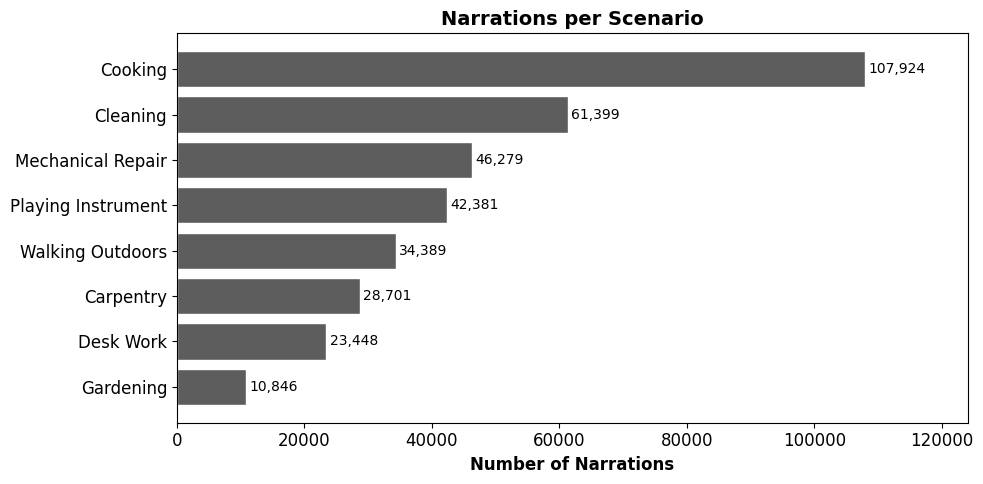

In [5]:
# Scenario distribution (horizontal bar - compact for poster)
scenario_counts = df_clean['scenario'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(scenario_counts.index, scenario_counts.values, color='#5D5D5D', edgecolor='white')
ax.set_xlabel('Number of Narrations', fontweight='bold')
ax.set_title('Narrations per Scenario', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add count labels
for bar, count in zip(bars, scenario_counts.values):
    ax.text(count + 500, bar.get_y() + bar.get_height()/2, f'{count:,}', 
            va='center', fontsize=10)

ax.set_xlim(0, max(scenario_counts.values) * 1.15)
plt.tight_layout()
plt.savefig(IMG_OUTPUT_DIR / 'scenario_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

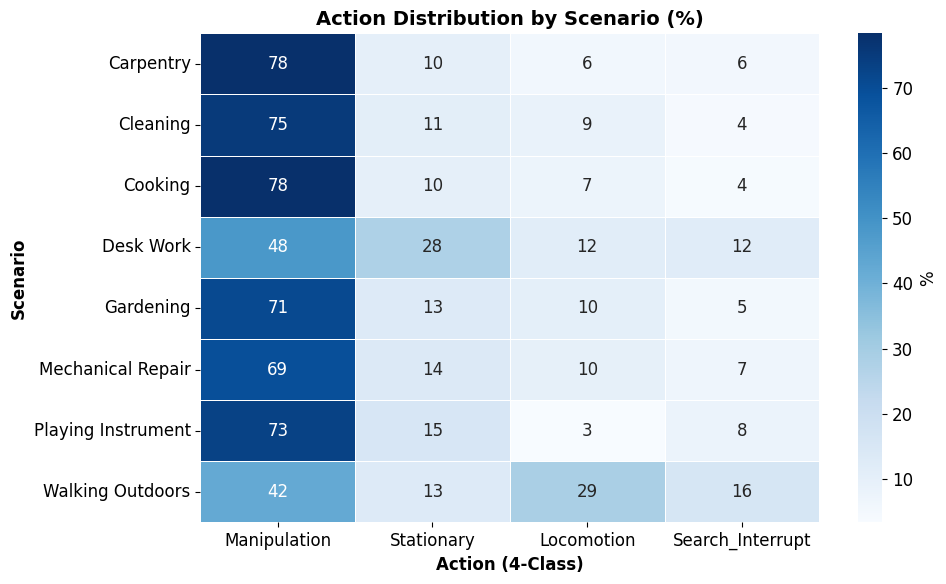

In [6]:
# Cross-tabulation: Scenario vs 4-Class Action (compact heatmap)
ct = pd.crosstab(df_clean['scenario'], df_clean['action_4class'], normalize='index') * 100

# Reorder columns
ct = ct[['Manipulation', 'Stationary', 'Locomotion', 'Search_Interrupt']]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': '%'}, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Action Distribution by Scenario (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Action (4-Class)', fontweight='bold')
ax.set_ylabel('Scenario', fontweight='bold')

plt.tight_layout()
plt.savefig(IMG_OUTPUT_DIR / 'scenario_action_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 4. IMU Data Coverage (Poster Figure)

In [7]:
# IMU Coverage Analysis - Check processed data
PROCESSED_DIR = Path('../data/processed')

# Count videos with processed IMU
processed_videos = set()
if PROCESSED_DIR.exists():
    for uid_dir in PROCESSED_DIR.iterdir():
        if uid_dir.is_dir() and (uid_dir / 'seq.npz').exists():
            processed_videos.add(uid_dir.name)

labeled_videos = set(df_clean['video_uid'].unique())
covered_videos = labeled_videos.intersection(processed_videos)

print(f"Labeled videos: {len(labeled_videos):,}")
print(f"Processed IMU: {len(processed_videos):,}")
print(f"Coverage: {len(covered_videos):,} ({len(covered_videos)/len(labeled_videos)*100:.1f}%)")

Labeled videos: 1,491
Processed IMU: 0
Coverage: 0 (0.0%)


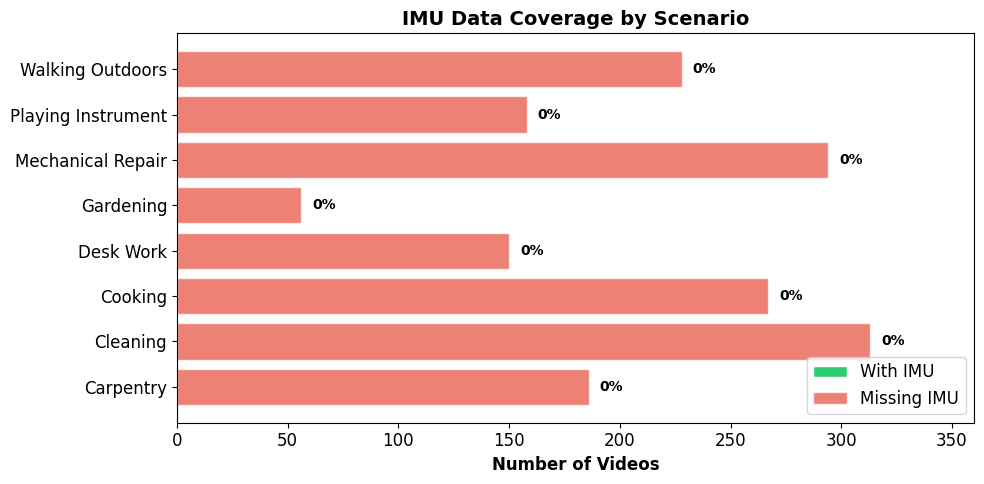


Saved: ../img/Label_EDA/ImuCoverage(good).png


In [8]:
# IMU Coverage by Scenario - Compact bar chart for poster
scenario_labels = pd.read_csv(SCENARIO_LABELS_PATH)

# Merge with processed status
scenario_labels['has_imu'] = scenario_labels['video_uid'].isin(processed_videos)

# Calculate coverage per scenario
coverage_by_scenario = scenario_labels.groupby('scenario').agg(
    total=('video_uid', 'count'),
    with_imu=('has_imu', 'sum')
).reset_index()
coverage_by_scenario['coverage_pct'] = (coverage_by_scenario['with_imu'] / coverage_by_scenario['total'] * 100).round(1)

# Sort by coverage
coverage_by_scenario = coverage_by_scenario.sort_values('with_imu', ascending=True)

# Create compact stacked bar chart
fig, ax = plt.subplots(figsize=(10, 5))

scenarios = coverage_by_scenario['scenario']
with_imu = coverage_by_scenario['with_imu']
without_imu = coverage_by_scenario['total'] - coverage_by_scenario['with_imu']

# Stacked bars
bars1 = ax.barh(scenarios, with_imu, label='With IMU', color='#2ECC71', edgecolor='white')
bars2 = ax.barh(scenarios, without_imu, left=with_imu, label='Missing IMU', color='#E74C3C', edgecolor='white', alpha=0.7)

ax.set_xlabel('Number of Videos', fontweight='bold')
ax.set_title('IMU Data Coverage by Scenario', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')

# Add labels
for i, (total, pct) in enumerate(zip(coverage_by_scenario['total'], coverage_by_scenario['coverage_pct'])):
    ax.text(total + 5, i, f'{pct:.0f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlim(0, coverage_by_scenario['total'].max() * 1.15)
plt.tight_layout()
plt.savefig(IMG_OUTPUT_DIR / 'ImuCoverage(good).png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print(f"\nSaved: {IMG_OUTPUT_DIR / 'ImuCoverage(good).png'}")

## 5. Label Mapping Comparison (6-Class → 4-Class)

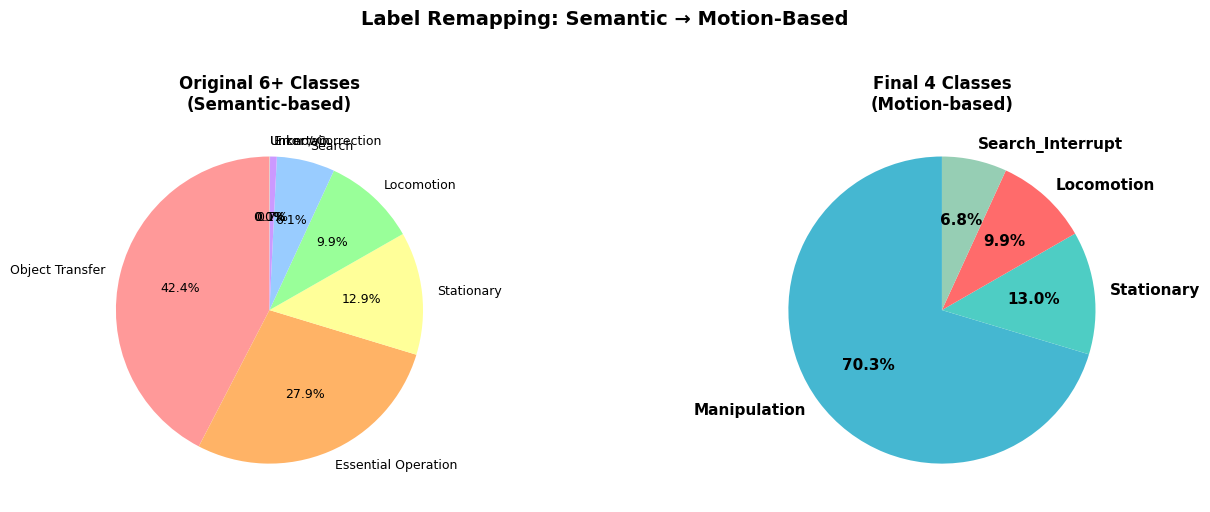


LABEL MAPPING TABLE
Original (6-class)        → Final (4-class)     
------------------------------------------------------------
Stationary                → Stationary          
Locomotion                → Locomotion          
Object Transfer           → Manipulation        
Essential Operation       → Manipulation        
Search                    → Search_Interrupt    
Error / Correction        → Search_Interrupt    
Unknown                   → DROPPED
Uncertain                 → DROPPED


In [9]:
# Show original 6-class vs final 4-class mapping
original_counts = df['action'].value_counts()
mapped_counts = df_clean['action_4class'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Original 6-class (old)
colors_6 = ['#FF9999', '#FFB366', '#FFFF99', '#99FF99', '#99CCFF', '#CC99FF', '#CCCCCC', '#999999']
ax1.pie(original_counts, labels=original_counts.index, autopct='%1.1f%%', 
        colors=colors_6[:len(original_counts)], startangle=90, textprops={'fontsize': 9})
ax1.set_title('Original 6+ Classes\n(Semantic-based)', fontsize=12, fontweight='bold')

# Final 4-class (new)
colors_4 = [ACTION_COLORS[label] for label in mapped_counts.index]
ax2.pie(mapped_counts, labels=mapped_counts.index, autopct='%1.1f%%',
        colors=colors_4, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Final 4 Classes\n(Motion-based)', fontsize=12, fontweight='bold')

plt.suptitle('Label Remapping: Semantic → Motion-Based', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMG_OUTPUT_DIR / 'label_mapping_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

# Print mapping table
print("\n" + "=" * 60)
print("LABEL MAPPING TABLE")
print("=" * 60)
print(f"{'Original (6-class)':<25} → {'Final (4-class)':<20}")
print("-" * 60)
for orig, final in ACTION_REMAP.items():
    if final:
        print(f"{orig:<25} → {final:<20}")
    else:
        print(f"{orig:<25} → DROPPED")
print("=" * 60)

## 6. Summary

In [10]:
print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)

print(f"\n📊 Dataset Statistics:")
print(f"   Videos: {df_clean['video_uid'].nunique():,}")
print(f"   Narrations: {len(df_clean):,}")
print(f"   Scenarios: {df_clean['scenario'].nunique()}")
print(f"   Action Classes: 4 (motion-based)")

print(f"\n🏷️  Action Distribution:")
for label in ['Manipulation', 'Stationary', 'Locomotion', 'Search_Interrupt']:
    count = (df_clean['action_4class'] == label).sum()
    pct = count / len(df_clean) * 100
    print(f"   {label}: {count:,} ({pct:.1f}%)")

print(f"\n📁 Generated Figures:")
for f in IMG_OUTPUT_DIR.glob('*.png'):
    print(f"   {f.name}")

print("\n" + "=" * 60)

FINAL DATASET SUMMARY

📊 Dataset Statistics:
   Videos: 1,491
   Narrations: 355,367
   Scenarios: 8
   Action Classes: 4 (motion-based)

🏷️  Action Distribution:
   Manipulation: 249,986 (70.3%)
   Stationary: 46,033 (13.0%)
   Locomotion: 35,060 (9.9%)
   Search_Interrupt: 24,288 (6.8%)

📁 Generated Figures:
   ImuCoverage(good).png
   label_mapping_comparison.png
   scenario_action_heatmap.png
   Label with imu.png
   motion_by_label_analysis.png
   imu_visualization_f6fea609-23c4-431c-8ac2-484f334a3a83.png
   scenario_distribution.png
   action_distribution_4class.png
   label_distribution.png

